El sistema astronómico de magnitudes y colores
===

Autores
---
J.P. Calderón & R. Gamen

Resumen
---
Los filtros astronómicos permiten registrar parte del espectro
electromagnético de las estrellas en determinados rangos de
longitud de onda. Combinando las magnitudes en distintos filtros
se definen índices de color que nos ayudan a clasificar las
estrellas y estudiar sus características. El objetivo de esta
práctica es familiarizar al estudiante con los sistemas de
filtros más modernos y utilizarlos para cálculos sencillos.

Referencias
---
* [Práctica 02 (overleaf)](https://www.overleaf.com/read/qxwzwbnpbdnr)

---
      
Ejercicios
---
Objetivos:
* Calcular la longitud de onda efectiva y equivalente, teniendo en cuenta la sensibilidad de un determinado filtro y el flujo emitido por una determinada fuente.
* Graficar la sensibilidad de un sistema de filtros.
* Calcular los colores instrumentales a partir de una fuente de energía.
* Convolucionar un espectro estelar con la sensibilidad de un filtro y obtener la magnitud integrada.

**1.** Graficar las sensibilidades de los filtros. Tanto desde un archivo descargado, como desde un dado _url_.

HOLAAA PRUEBA

In [43]:
#from google.colab import files

# Esto abrirá un selector de archivos en tu navegador
#uploaded = files.upload()

# Verificamos si el archivo se subió correctamente
#for fn in uploaded.keys():
#  print('Archivo "{name}" subido con éxito ({length} bytes)'.format(
#      name=fn, length=len(uploaded[fn])))

In [44]:
import pandas as pd
data = pd.read_csv('data/UBVRI.dat', names = [ 'filtro','long','sen','sen_nor' ],
                    sep =r"\s+", comment = '#', header = None )
data # Se accede a cada columna mediante: data[0], data[1], ...

,filtro,long,sen,sen_nor
0,B,3600,0.00,0.00
1,B,3650,0.00,0.00
2,B,3700,0.02,0.02
3,B,3750,0.05,0.05
4,B,3800,0.11,0.11
...,...,...,...,...
304,V,7150,0.01,0.01
305,V,7200,0.01,0.01
306,V,7250,0.01,0.01
307,V,7300,0.01,0.01


In [45]:
#data.query("filtro=='B'")

dataB = data[ data['filtro'] == 'B' ]
dataB

,filtro,long,sen,sen_nor
0,B,3600,0.00,0.00
1,B,3650,0.00,0.00
2,B,3700,0.02,0.02
3,B,3750,0.05,0.05
4,B,3800,0.11,0.11
5,B,3850,0.18,0.18
6,B,3900,0.35,0.35
7,B,3950,0.55,0.55
8,B,4000,0.92,0.92
9,B,4050,0.95,0.95


In [46]:
data.query("filtro=='B'").long # .mean() goteaaaaaa promedeio // o con .head()

0     3600
1     3650
2     3700
3     3750
4     3800
5     3850
6     3900
7     3950
8     4000
9     4050
10    4100
11    4150
12    4200
13    4250
14    4300
15    4350
16    4400
17    4450
18    4500
19    4550
20    4600
21    4650
22    4700
23    4750
24    4800
25    4850
26    4900
27    4950
28    5000
29    5050
30    5100
31    5150
32    5200
33    5250
34    5300
35    5350
36    5400
37    5450
38    5500
39    5550
Name: long, dtype: int64

<>:40: SyntaxWarning: invalid escape sequence '\A'
<>:40: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Mateo\AppData\Local\Temp\ipykernel_20440\4200410204.py:40: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel ( 'long. de onda [$\AA$]' )


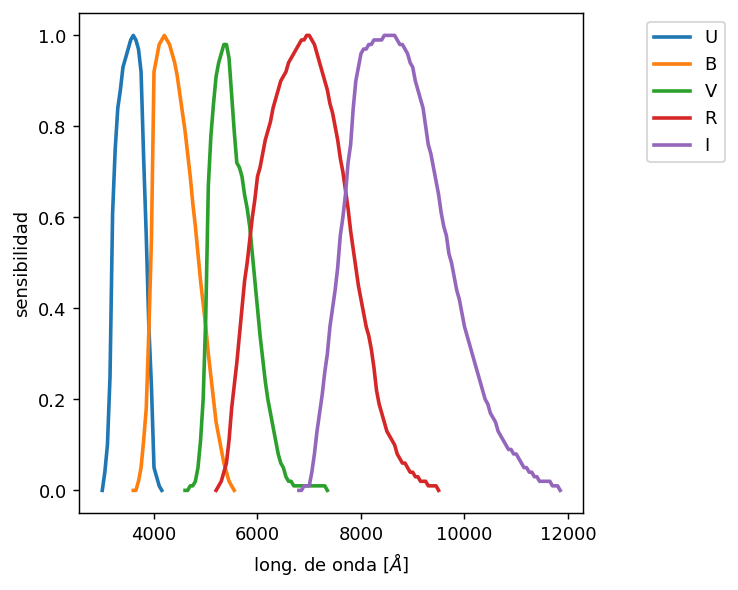

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.plot (
    data[ (data['filtro']=='U') ]['long'],
    data[ (data['filtro']=='U') ]['sen'],
    linewidth = 2, label = "U"
)

ax.plot (
    data[ (data['filtro']=='B') ]['long'],
    data[ (data['filtro']=='B') ]['sen'],
    linewidth = 2, label = "B"
)

ax.plot (
    data[ (data['filtro']=='V') ]['long'],
    data[ (data['filtro']=='V') ]['sen'],
    linewidth = 2, label = "V"
)

ax.plot (
    data[ (data['filtro']=='R') ]['long'],
    data[ (data['filtro']=='R') ]['sen'],
    linewidth = 2, label = "R"
)

ax.plot (
    data[ (data['filtro']=='I') ]['long'],
    data[ (data['filtro']=='I') ]['sen'],
    linewidth = 2, label = "I"
)


#V:
λe = 5480
#Å

ax.set_xlabel ( 'long. de onda [$\AA$]' )
ax.set_ylabel ( 'sensibilidad' )

plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

#TODOS LOS GRAFICOS EN ESTE MISMO DEL PUNTO 1.

¿Cómo filtrar el archivo de entrada en bandas (U, B, V)?

In [48]:
dataU = data[ data['filtro'] == 'U' ]
dataU

,filtro,long,sen,sen_nor
229,U,3000,0.00,0.00
230,U,3050,0.04,0.04
231,U,3100,0.10,0.10
232,U,3150,0.25,0.25
233,U,3200,0.61,0.61
234,U,3250,0.75,0.75
235,U,3300,0.84,0.84
236,U,3350,0.88,0.88
237,U,3400,0.93,0.93
238,U,3450,0.95,0.95


In [49]:
dataV = data[ data['filtro'] == 'V' ]
dataB = data[ data['filtro'] == 'B' ]

<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Mateo\AppData\Local\Temp\ipykernel_20440\3246448857.py:4: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel ( 'long. de onda [$\AA$]' )


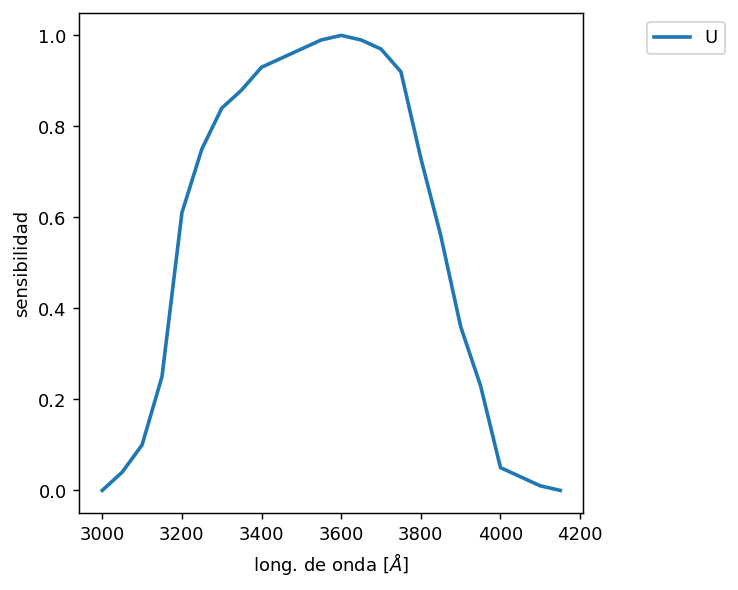

In [50]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )
ax.plot ( dataU['long'], dataU['sen'], linewidth = 2, label = "U" )

ax.set_xlabel ( 'long. de onda [$\AA$]' )
ax.set_ylabel ( 'sensibilidad' )

plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

Descargo el archivo de sensibilidades de la página de GEMINI:

In [51]:
gmos_Ha = pd.read_csv('gmos_n_Ha_G0310.txt',
                     sep = "    ", comment = '#', header = None )

gmos_g = pd.read_csv('gmos_n_g_G0301.txt',
                     sep = "  ", comment = '#', header = None )

gmos_i = pd.read_csv('gmos_n_i_G0302.txt',
                     sep = "  ", comment = '#', header = None )

gmos_r = pd.read_csv('gmos_n_r_G0303.txt',
                     sep = "  ", comment = '#', header = None )

gmos_u = pd.read_csv('gmos_n_u_G0308.txt',
                     sep = "   ", comment = '#', header = None )

C:\Users\Mateo\AppData\Local\Temp\ipykernel_20440\709881006.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  gmos_Ha = pd.read_csv('gmos_n_Ha_G0310.txt',
C:\Users\Mateo\AppData\Local\Temp\ipykernel_20440\709881006.py:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  gmos_g = pd.read_csv('gmos_n_g_G0301.txt',
C:\Users\Mateo\AppData\Local\Temp\ipykernel_20440\709881006.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='py

<>:9: SyntaxWarning: invalid escape sequence '\A'
<>:9: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Mateo\AppData\Local\Temp\ipykernel_20440\3445500914.py:9: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel ( 'long. de onda [$\AA$]' )


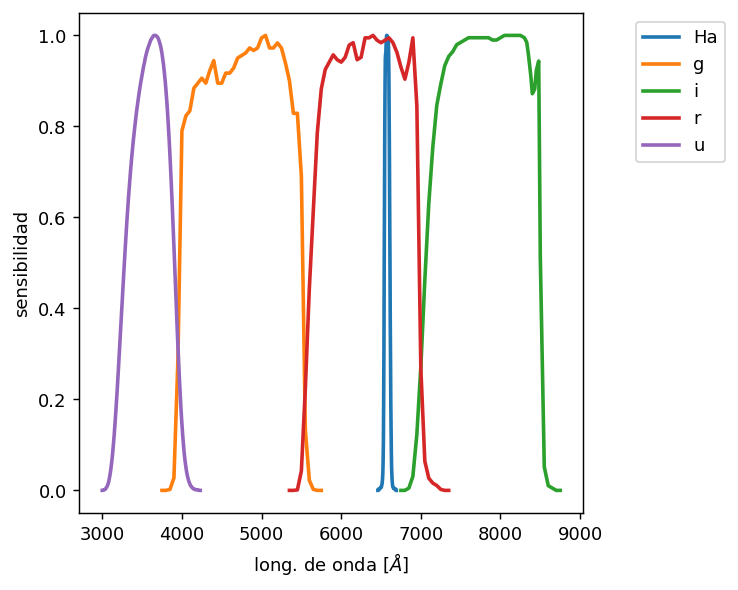

In [52]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )

ax.plot ( gmos_Ha[0] * 10., gmos_Ha[1]/ gmos_Ha[1].max(), linewidth = 2, label = "Ha" ) # Paso la long. de onda a \AA
ax.plot ( gmos_g[0] * 10., gmos_g[1]/ gmos_g[1].max(), linewidth = 2, label = "g" ) # Paso la long. de onda a \AA
ax.plot ( gmos_i[0] * 10., gmos_i[1]/ gmos_i[1].max(), linewidth = 2, label = "i" ) # Paso la long. de onda a \AA
ax.plot ( gmos_r[0] * 10., gmos_r[1]/ gmos_r[1].max(), linewidth = 2, label = "r" ) # Paso la long. de onda a \AA
ax.plot ( gmos_u[0] * 10., gmos_u[1]/ gmos_u[1].max(), linewidth = 2, label = "u" ) # Paso la long. de onda a \AA

ax.set_xlabel ( 'long. de onda [$\AA$]' )
ax.set_ylabel ( 'sensibilidad' )

plt.legend ( bbox_to_anchor = (1.3,1), ncol = 1 )
plt.show()

**2.** Calcular la longitud de onda equivalente y efectiva

Sin considerar la radiación proveniente de la fuente, se puede definir
la longitud de onda media o equivalente $\lambda_{0}$ de un filtro,
de la siguiente forma:

\begin{equation}
  \lambda_{0} = \frac{\int \lambda ~ S(\lambda) ~ d\lambda }{\int S(\lambda) ~ d\lambda}
\end{equation}

me va a dar la parte roja (uno tir el maximo de filtro y el otro lo que se filtra).
la idea es hacerlo analiticamente.

en donde $S(\lambda)$ representa la función de transmición del
filtro. Si, por lo contrario, se tiene en cuenta la distribución de
energía de la fuente, se puede definir la longitud de onda efectiva
$\lambda_{e}$:

\begin{equation}
  \lambda_{e} = \frac{\int \lambda ~ S(\lambda) ~ F(\lambda) ~ d\lambda }{\int S(\lambda) ~ F(\lambda) ~ d\lambda}
\end{equation}

en donde $F(\lambda)$ es la distribución de energía de la fuente.

Para hacer lo anterior, utilizaremos el método de integración para datos provenientes de un archivo de texto:

En este caso vamos a mostrar cómo integrar mediante el [método de Simpson](https://es.wikipedia.org/wiki/Regla_de_Simpson) (```simp``` de ```scipy```) y vamos a usar el módelo de cuerpo negro (```BlackBody``` de ```astropy```).
El método de Simpson utiliza subintervalos de la dada función $f(x)$ aproximando por un polinomio de primer grado $P(x)$:

\begin{equation}
\int_a^b f(x)\ dx \equiv \frac{\Delta x}{3} \sum_{i = 1}^{N/2} \left[f(x_{2i-2}) + 4 f(x_{2i-1}) + f(x_{2i}) \right]
\end{equation}

dónde $\Delta x = (b-a)/N$, $x_{i} = a + i \Delta x$.

Manual de ```simp```: https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.integrate.simps.html

In [53]:
from astropy.modeling.models import BlackBody
from astropy import units as u

bb = BlackBody ( temperature = 6000 * u.K )
print(bb(4000 * u.AA))


1.5504456087808982e-05 erg / (Hz s sr cm2)


In [54]:
from scipy.integrate import simpson
import numpy as np

dataV = data[ data['filtro'] == 'V' ]
dataU = data[ data['filtro'] == 'U' ]
dataR = data[ data['filtro'] == 'R' ]
dataB = data[ data['filtro'] == 'B' ]
dataI = data[ data['filtro'] == 'I' ]

LOM_numerador = simpson( dataV['long'] * dataV['sen'], x = dataV['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataV['sen'], x = dataV['long'] )

print ( "[*] Long. de onda media para el filtro V [$AA$] = ", LOM_numerador/LOM_denominador)

LOM_numerador = simpson( dataU['long'] * dataU['sen'], x = dataU['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataU['sen'], x = dataU['long'] )

print ( "[*] Long. de onda media para el filtro U [$AA$] = ", LOM_numerador/LOM_denominador)

LOM_numerador = simpson( dataR['long'] * dataR['sen'], x = dataR['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataR['sen'], x = dataR['long'] )

print ( "[*] Long. de onda media para el filtro R [$AA$] = ", LOM_numerador/LOM_denominador)

LOM_numerador = simpson( dataB['long'] * dataB['sen'], x = dataB['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataB['sen'], x = dataB['long'] )

print ( "[*] Long. de onda media para el filtro B [$AA$] = ", LOM_numerador/LOM_denominador)

LOM_numerador = simpson( dataI['long'] * dataI['sen'], x = dataI['long'] ) # Borrar el argumento
LOM_denominador = simpson( dataI['sen'], x = dataI['long'] )

print ( "[*] Long. de onda media para el filtro I [$AA$] = ", LOM_numerador/LOM_denominador)
# Para la integral por Simpson, _python_u tiene:
# integral = simpson integrando['X'], x = X )

#me hace la division esa que aparecen arriba, la que tiene los lambda

[*] Long. de onda media para el filtro V [$AA$] =  5535.53009270152
[*] Long. de onda media para el filtro U [$AA$] =  3537.8678564647807
[*] Long. de onda media para el filtro R [$AA$] =  6936.422136422137
[*] Long. de onda media para el filtro B [$AA$] =  4440.611526616806
[*] Long. de onda media para el filtro I [$AA$] =  8776.57390552061


In [55]:
# Faltaría calcular la long de onda efectiva.
# Define the BlackBody radiation function at T=6000K
bb_6000K = BlackBody(temperature=6000 * u.K)

filters = {'U': dataU, 'B': dataB, 'V': dataV}

print("[*] Longitudes de Onda Efectivas (para un Cuerpo Negro a 6000 K):")

for filter_name, filter_data in filters.items():
    # Get filter wavelengths and sensitivities
    filter_wavelengths = filter_data['long'].values * u.AA # Convert to Angstrom units
    filter_sensitivity = filter_data['sen'].values

    # Calculate BlackBody flux at these wavelengths
    # The BlackBody model returns spectral flux density per unit wavelength
    blackbody_flux = bb_6000K(filter_wavelengths).value # Extract numerical value

    # Calculate the numerator: integral of (λ * S(λ) * F(λ))
    numerator = simpson(filter_data['long'] * filter_sensitivity * blackbody_flux, x=filter_data['long'])

    # Calculate the denominator: integral of (S(λ) * F(λ))
    denominator = simpson(filter_sensitivity * blackbody_flux, x=filter_data['long'])

    # Calculate effective wavelength
    effective_wavelength = numerator / denominator
    print(f"    Filtro {filter_name}: {effective_wavelength:.2f} Å")

[*] Longitudes de Onda Efectivas (para un Cuerpo Negro a 6000 K):
    Filtro U: 3585.97 Å
    Filtro B: 4506.29 Å
    Filtro V: 5569.04 Å


**3.** Vamos a unir los archivos de la distribución de energia $F(\lambda)$ y la sensibilidad $S(\lambda)$ del filtro para calcular el índice de color


\begin{equation}
  m_{V} = C_{0V} - 2.5\ log\left(\int F(\lambda)\ S(\lambda)\ d\lambda\right)
\end{equation}

dónde $C_{0V}$ es el punto de cero del filtro. Luego, calculando lo mismo para el filtro B, se puede obtener el índice de color

\begin{equation}
  (b-v) = m_{B} - m_{v}
\end{equation}

agarrar una tabla y hacer las 2 cosas al mismo tiempo, tambien podemos porbar hacerlo con un for para que se amas pro

In [56]:
# Primer parte
# Defino una matriz con los puntos de cero de cada filtro
C = pd.DataFrame ( {"C0": [21.100, 21.750, 20.830]}, index = ['V', 'B', 'U'] )
print (C)

      C0
V  21.10
B  21.75
U  20.83


In [57]:
print ( C.loc['V','C0'] )

21.1


In [58]:
# Segunda parte
distribucion = pd.read_csv("data/distribucion_espectral_K5V.dat", names = ['long2', 'int'],
                           sep = " ", comment = '#', header = None)
distribucion['long2'] = distribucion['long2'] * 10. # Para convertir la long. de onda de nm a AA.
print ( distribucion )

#como leerlo cn el .query

       long2   int
0     1200.0   0.0
1     1250.0   0.0
2     1300.0   0.0
3     1350.0   0.0
4     1400.0   0.0
..       ...   ...
183  10350.0  80.5
184  10400.0  81.2
185  10450.0  80.0
186  10500.0  78.5
187  12500.0  54.0

[188 rows x 2 columns]


In [59]:
# Segunda parte
distribucion2 = pd.read_csv("estrella2.dat", names = ['long2', 'int'],
                           sep = "\s+", comment = '#', header = None, engine='python')
distribucion2['long2'] = distribucion2['long2'] * 10. # Para convertir la long. de onda de nm a AA.
print ( distribucion2 )

#como leerlo cn el .query

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Mateo\AppData\Local\Temp\ipykernel_20440\1378345892.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep = "\s+", comment = '#', header = None, engine='python')


FileNotFoundError: [Errno 2] No such file or directory: 'estrella2.dat'

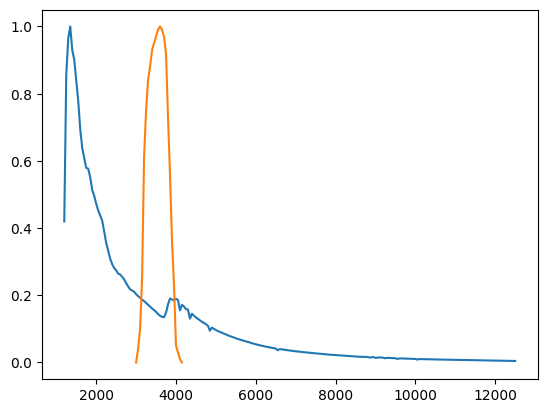

In [ ]:
plt.plot(distribucion2['long2'], distribucion2['int']/distribucion2['int'].max())
plt.plot(dataV['long'], dataV['sen'])
plt.show()

# Grafico la distribución espectral normalizada y la sensibilidad del filtro V.
# La superposición muestra qué parte del espectro es registrada por ese filtro.

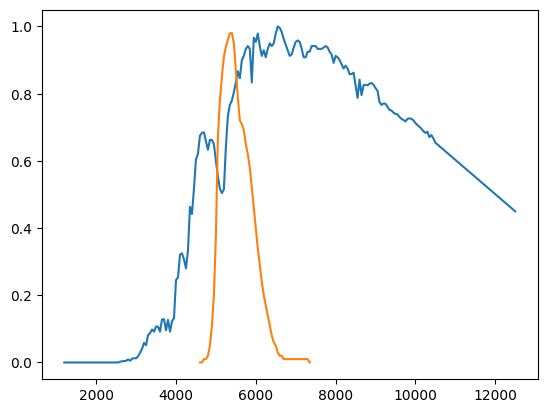

In [ ]:
plt.plot(distribucion['long2'], distribucion['int']/distribucion['int'].max())
plt.plot(dataV['long'], dataV['sen'])
plt.show()


In [ ]:
# Tercer parte

#  Filtro la distribución de la fuente según la long. de onda
#   disponible en el archivo de sensibilidades.

min = dataV['long'].min() # Calculo el minimo y máximo
max = dataV['long'].max() #  de las long. de onda.
print ( "[*] min y máx de la long. de onda (V) = ", min, max )

[*] min y máx de la long. de onda (V) =  4600 7350


In [ ]:
dist_filtrada = distribucion[ (distribucion['long2'] >= min) & (distribucion['long2'] <= max) ] # Filtro por banda.
##      Notar: el espaciado en de la sensibilidad y de la distribucion es la misma (50 AA),
##             por lo que no hay que hacer ninguna interpolación.
print ( dist_filtrada )

      long2    int
68   4600.0   81.0
69   4650.0   82.0
70   4700.0   82.2
71   4750.0   79.0
72   4800.0   76.0
73   4850.0   79.5
74   4900.0   79.5
75   4950.0   78.0
76   5000.0   72.0
77   5050.0   66.5
78   5100.0   62.0
79   5150.0   60.5
80   5200.0   61.8
81   5250.0   77.0
82   5300.0   88.0
83   5350.0   92.0
84   5400.0   93.5
85   5450.0   96.5
86   5500.0  100.0
87   5550.0  104.0
88   5600.0  101.5
89   5650.0  108.0
90   5700.0  109.5
91   5750.0  112.0
92   5800.0  113.0
93   5850.0  112.0
94   5900.0  100.0
95   5950.0  116.0
96   6000.0  114.5
97   6050.0  117.5
98   6100.0  113.0
99   6150.0  109.5
100  6200.0  111.5
101  6250.0  109.0
102  6300.0  112.0
103  6350.0  114.0
104  6400.0  113.0
105  6450.0  114.0
106  6500.0  117.5
107  6550.0  120.0
108  6600.0  119.5
109  6650.0  118.0
110  6700.0  115.5
111  6750.0  113.5
112  6800.0  111.5
113  6850.0  109.5
114  6900.0  110.0
115  6950.0  112.5
116  7000.0  114.5
117  7050.0  115.0
118  7100.0  114.5
119  7150.0 

In [ ]:
dist_filtrada2 = distribucion2[ (distribucion2['long2'] >= min) & (distribucion2['long2'] <= max) ] # Filtro por banda.
##      Notar: el espaciado en de la sensibilidad y de la distribucion es la misma (50 AA),
##             por lo que no hay que hacer ninguna interpolación.
print ( dist_filtrada2 )

      long2    int
68   4600.0  174.0
69   4650.0  168.0
70   4700.0  163.0
71   4750.0  158.0
72   4800.0  152.0
73   4850.0  131.0
74   4900.0  144.0
75   4950.0  139.0
76   5000.0  134.0
77   5050.0  130.0
78   5100.0  126.0
79   5150.0  123.0
80   5200.0  119.0
81   5250.0  116.0
82   5300.0  112.0
83   5350.0  109.0
84   5400.0  106.0
85   5450.0  103.0
86   5500.0  100.0
87   5550.0   97.0
88   5600.0   94.5
89   5650.0   92.0
90   5700.0   89.6
91   5750.0   87.2
92   5800.0   85.0
93   5850.0   82.4
94   5900.0   79.6
95   5950.0   77.2
96   6000.0   75.0
97   6050.0   73.0
98   6100.0   71.0
99   6150.0   69.0
100  6200.0   67.2
101  6250.0   65.4
102  6300.0   63.7
103  6350.0   62.0
104  6400.0   60.4
105  6450.0   59.0
106  6500.0   57.5
107  6550.0   50.4
108  6600.0   55.2
109  6650.0   54.0
110  6700.0   52.6
111  6750.0   51.5
112  6800.0   50.4
113  6850.0   49.2
114  6900.0   48.0
115  6950.0   47.2
116  7000.0   46.2
117  7050.0   45.3
118  7100.0   44.4
119  7150.0 

In [ ]:
# Noten que ambas matrices tienen el mismo tamaño
print ( len(dist_filtrada2), len(dataV) )

56 56


In [ ]:
# Cuarta parte
dataV = dataV.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada = dist_filtrada.reset_index ( drop = True )

# como tienen el mismo tamaño, lo puedo pegar:
output = dist_filtrada.join(dataV)
print(output)

#ver el join

     long2    int filtro  long   sen  sen_nor
0   4600.0  174.0      V  4600  0.00    0.000
1   4650.0  168.0      V  4650  0.00    0.000
2   4700.0  163.0      V  4700  0.01    0.010
3   4750.0  158.0      V  4750  0.01    0.010
4   4800.0  152.0      V  4800  0.02    0.020
5   4850.0  131.0      V  4850  0.05    0.051
6   4900.0  144.0      V  4900  0.11    0.112
7   4950.0  139.0      V  4950  0.20    0.204
8   5000.0  134.0      V  5000  0.38    0.388
9   5050.0  130.0      V  5050  0.67    0.684
10  5100.0  126.0      V  5100  0.78    0.796
11  5150.0  123.0      V  5150  0.85    0.867
12  5200.0  119.0      V  5200  0.91    0.929
13  5250.0  116.0      V  5250  0.94    0.959
14  5300.0  112.0      V  5300  0.96    0.980
15  5350.0  109.0      V  5350  0.98    1.000
16  5400.0  106.0      V  5400  0.98    1.000
17  5450.0  103.0      V  5450  0.95    0.969
18  5500.0  100.0      V  5500  0.87    0.888
19  5550.0   97.0      V  5550  0.79    0.806
20  5600.0   94.5      V  5600  0.

In [ ]:
# Cuarta parte
dataV = dataV.reset_index ( drop = True ) # Vuelve a cero los indices.
dist_filtrada2 = dist_filtrada2.reset_index ( drop = True )

# como tienen el mismo tamaño, lo puedo pegar:
output2 = dist_filtrada2.join(dataV)
print(output2)

#ver el join

     long2    int filtro  long   sen  sen_nor
0   4600.0  174.0      V  4600  0.00    0.000
1   4650.0  168.0      V  4650  0.00    0.000
2   4700.0  163.0      V  4700  0.01    0.010
3   4750.0  158.0      V  4750  0.01    0.010
4   4800.0  152.0      V  4800  0.02    0.020
5   4850.0  131.0      V  4850  0.05    0.051
6   4900.0  144.0      V  4900  0.11    0.112
7   4950.0  139.0      V  4950  0.20    0.204
8   5000.0  134.0      V  5000  0.38    0.388
9   5050.0  130.0      V  5050  0.67    0.684
10  5100.0  126.0      V  5100  0.78    0.796
11  5150.0  123.0      V  5150  0.85    0.867
12  5200.0  119.0      V  5200  0.91    0.929
13  5250.0  116.0      V  5250  0.94    0.959
14  5300.0  112.0      V  5300  0.96    0.980
15  5350.0  109.0      V  5350  0.98    1.000
16  5400.0  106.0      V  5400  0.98    1.000
17  5450.0  103.0      V  5450  0.95    0.969
18  5500.0  100.0      V  5500  0.87    0.888
19  5550.0   97.0      V  5550  0.79    0.806
20  5600.0   94.5      V  5600  0.

In [ ]:
# Quinta parte

V = C.loc['V','C0'] - 2.5 * np.log10 ( simpson(output['int']*output['sen'], x = output['long']) )
print ("[*]  V = ", V)

B = C.loc['B','C0'] - 2.5 * np.log10 ( simpson(output['int']*output['sen'], x = output['long']) )
print ("[*]  B = ", B)

U = C.loc['U','C0'] - 2.5 * np.log10 ( simpson(output['int']*output['sen'], x = output['long']) )
print ("[*]  U = ", U)

[*]  V =  8.800712760638728
[*]  B =  9.450712760638726
[*]  U =  8.530712760638725


In [ ]:
# Quinta parte

V2 = C.loc['V','C0'] - 2.5 * np.log10 ( simpson(output2['int']*output2['sen'], x = output2['long']) )
print ("[*]  V2 = ", V2)

B2 = C.loc['B','C0'] - 2.5 * np.log10 ( simpson(output2['int']*output2['sen'], x = output2['long']) )
print ("[*]  B2 = ", B2)

U2 = C.loc['U','C0'] - 2.5 * np.log10 ( simpson(output2['int']*output2['sen'], x = output2['long']) )
print ("[*]  U2 = ", U2)

[*]  V2 =  8.727161820210991
[*]  B2 =  9.37716182021099
[*]  U2 =  8.457161820210988


In [ ]:
# Falta calculo en los filtros U, y B

In [ ]:
print ("[*] color instrumental (b-v) = ", B2-V2)

[*] color instrumental (b-v) =  0.6499999999999986


In [ ]:
print ("[*] color instrumental (u-b) = ", U2-B2)

[*] color instrumental (u-b) =  -0.9200000000000017


<>:15: SyntaxWarning: invalid escape sequence '\A'
<>:15: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_9015/3811347651.py:15: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Longitud de onda ($\AA$)")


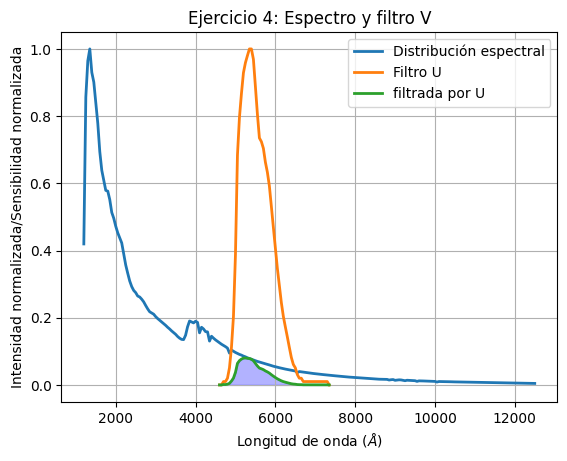

In [ ]:
data_ = pd.read_csv ( 'estrella2.dat', names = ['long3','int'],
                    sep =r"\s+", comment = '#', header = None)

plt.plot ( data_['long3'] * 10, data_['int']/data_['int'].max(), linewidth = 2, label = "Distribución espectral" ) #max es para normalizar la intensidad a 1, y asi poder comparar con la sensibilidad de los filtros.
plt.plot (dataV.long, dataV.sen_nor, linewidth = 2, label = "Filtro U" )

minV = dataV.long.min()
maxV = dataV.long.max()
dist_filtrada_V = data_[ (data_['long3'] * 10 >= minV) & (data_['long3'] * 10 <= maxV) ].reset_index ( drop = True ) # Filtro por banda y reseteo los indices.
output_V = dist_filtrada_V.join(dataV.reset_index(drop=True))  #OJO, long3 en la tabla sigue guardado en nanometros, tan solo multiplico por 10 para filtrar y hacer coincidir indices.

plt.plot (dataV.long, (output_V.sen_nor) * (output_V.int/data_['int'].max()), linewidth = 2, label = "filtrada por U")

plt.fill_between(dataV.long, (output_V.sen_nor) * (output_V.int/data_['int'].max()),0, color='blue', alpha=0.3)
plt.xlabel("Longitud de onda ($\AA$)")
plt.ylabel("Intensidad normalizada/Sensibilidad normalizada")
plt.title("Ejercicio 4: Espectro y filtro V")
plt.legend()
plt.grid(True)
plt.show()

**3.** Diagrama color-color

In [ ]:
import matplotlib.pyplot as plt

diagrama = pd.read_csv ( 'V.dat', sep = " ", comment = '#' )

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (5, 5), dpi = 130 )
ax.plot( 'B-V', 'U-B', data = diagrama, marker = 'o',
         markerfacecolor = 'red', markersize = 12, color = 'darkred', linewidth = 4 )

# Agrega el tipo espectral
for i in diagrama.index:
    plt.annotate ( diagrama.loc[i]['Sp'], xy = ( diagrama.loc[i]['B-V'], diagrama.loc[i]['U-B'] ),
                xytext = (10, -5), textcoords = 'offset points',
                family = 'sans-serif', fontsize = 10, color = 'black' )

ax.set_xlabel('(B-V)')
ax.set_ylabel('(U-B)')
plt.gca().invert_yaxis()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'V.dat'

**4.** Descargo la distribución espectral de una estrella tipo A0 de Vizier (en formato pandas) y convoluciono con la sensibilidad del filtro V (que ya teniamos cargado).

In [ ]:
A0 = pd.read_csv("http://cdsarc.u-strasbg.fr/viz-bin/nph-Plot/Vgraph/txt?VI%2f50&I%28A0V%29",
                 names = ['l','I'], sep = "\t", comment = '#', header = None)
A0['l'] = A0['l'] * 10. # Para convertir la long. de onda de nm a AA.

In [ ]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (10, 5), dpi = 130 )
ax.plot ( A0['l'], A0['I']/A0['I'].max() ) # Normalizo con el máximo de la distribución
ax.plot ( dataV['long'], dataV['sen'] )

## Filtro la distribución, teniendo en cuenta el máx y mín del archivo de sensibilidades
A0_filtrada =  A0[(A0['l'] >= dataV['long'].min()) & (A0['l'] <= dataV['long'].max())] # Filtro por banda

dataV = dataV.reset_index(drop=True) # Vuelve a cero los indices.
A0_filtrada = A0_filtrada.reset_index(drop=True)

output = A0_filtrada.join(dataV) # Junto las matrices
#print (output)
##

ax.plot ( output['long'], output['I']*output['sen']/A0['I'].max() )

ax.fill_between( output['long'], 0, output['I']*output['sen']/A0['I'].max(),
                 color = "red", interpolate = True )

plt.legend(labels = ['A0','S$_{V}$'] )

plt.xlabel('Long. de onda [$\AA$]')
plt.ylabel('Intensidad normalizada')

plt.show()